In [1]:
import numpy as np
import matplotlib.pyplot as plt
import emcee
import corner
import pandas as pd
from scipy import interpolate

In [2]:
plt.style.use('/Users/thepoetoftwilight/Documents/CUBS/Code/science.mplstyle')

# Constants

In [3]:
# List of atmoic numbers
A_dict = {'H' : 1.00797 ,
'He' : 4.00260 ,
'Li' : 6.941 ,
'Be' : 9.01218 ,
'B' : 10.81 ,
'C' : 12.011 ,
'N' : 14.0067 ,
'O' : 15.994 ,
'F' : 18.9994 ,
'Ne' : 20.179 ,
'Na' : 22.98977 ,
'Mg' : 24.305 ,
'Al' : 26.98154 ,
'Si' : 28.0855 ,
'P' : 30.97376 ,
'S' : 32.06 ,
'Cl' : 35.453 ,
'A' : 39.948 ,
'K' : 39.0983 ,
'Ca' : 40.08 ,
'Sc' : 44.9559 ,
'Ti' : 47.90 ,
'V' : 50.9415 ,
'Te' : 51.996 ,
'Mn' : 54.9380 ,
'Fe' : 55.847 ,
'Co' : 58.70 ,
'Ni' : 58.9332 ,
'Cu' : 63.546 ,
'Zn' : 65.38,
}

In [4]:
# Significance levels
# Sigma values taken from Gehrels 1986
cdf_1sig = 0.8413
cdf_2sig = 0.9772
cdf_3sig = 0.9987

In [5]:
# Boltzmann constant, adjusted to use km instead of m
k_B = 1.380649e-29
# Mass of hydrogen atom
amu = 1.66054e-27

# Functions

In [6]:
def gen_b(logT, b_NT, A):
    
    return np.sqrt((2*k_B*10**logT/(A*amu)) + b_NT**2)

In [7]:
def log_prior(params):

    # Grid parameters being varied
    logT, b_NT = params
    
    # Avoid edges?
    if 4<logT<6 and 0<b_NT<50:
        return np.log(10**logT)
    return -np.inf

In [8]:
def log_likelihood(params, b_list):
    
    logT, b_NT = params

    #print(logT, b_NT)
    
    ll = 0
    
    for i in range(len(b_list)):
        
        ybar = gen_b(logT, b_NT, A_dict[b_list[i][1]])
        y = b_list[i][2]
        dy = b_list[i][3]
        
        ll += -.5*(y-ybar)**2/dy**2
            
    return ll

In [9]:
def log_probability(params, b_list):
        
    lp = log_prior(params)
    
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(params, b_list)

In [10]:
gen_b(4.5, 0, A_dict['H'])

22.840634549308316

In [11]:
gen_b(4.8, 0, A_dict['C'])

9.346357414756273

In [12]:
gen_b(5, 0, A_dict['Mg'])

8.271497744829851

In [13]:
gen_b(4, 0, A_dict['N'])

3.445593622658098

In [14]:
gen_b(5.8, 0, A_dict['O'])

25.6125855804167

In [15]:
gen_b(4, 0, A_dict['Si'])

2.433273287255247

# z=0.67

## c1

### c1L

In [51]:
b_list = [[['HI', 'H', 36, 2],
          ['CIII', 'C', 31, 2]
          ]]

In [52]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(200, 2)
nwalkers, ndim = pos.shape

In [53]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [54]:
sampler.run_mcmc(pos, 5000, progress=True)

100%|██████████████████████████████████████████████████████| 5000/5000 [00:10<00:00, 457.11it/s]


State([[ 4.1179368  32.1687032 ]
 [ 4.34085254 32.10195711]
 [ 4.192386   30.52382499]
 [ 4.29265447 30.41109267]
 [ 4.34640048 29.17700483]
 [ 4.38154925 30.22904449]
 [ 4.41424205 30.74816478]
 [ 4.58816337 29.08128459]
 [ 4.52095585 28.48563026]
 [ 4.39751255 33.03616915]
 [ 4.53803348 29.22054388]
 [ 4.3466039  27.02220103]
 [ 4.42281723 28.35509971]
 [ 4.6669266  27.54857127]
 [ 4.3700646  29.41467184]
 [ 4.38736618 34.12047483]
 [ 4.30365769 29.70092199]
 [ 4.5737062  29.89017639]
 [ 4.51322473 27.75101468]
 [ 4.38099613 32.54111361]
 [ 4.13752532 31.95410997]
 [ 4.18166494 33.59452046]
 [ 4.11841151 32.72570667]
 [ 4.54332271 32.90516478]
 [ 4.66260722 28.11111541]
 [ 4.34409411 29.70862699]
 [ 4.65581279 30.94360395]
 [ 4.21315939 30.23096937]
 [ 4.08771554 30.8582241 ]
 [ 4.53350987 25.8498053 ]
 [ 4.37313916 31.14966182]
 [ 4.38372548 28.62145451]
 [ 4.41919614 29.28777257]
 [ 4.40530237 28.70742599]
 [ 4.47279615 33.95779684]
 [ 4.2087955  30.7748851 ]
 [ 4.1134057  32.77109

In [55]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=500, flat=True), 
                                columns=['logT', 'b_NT'])

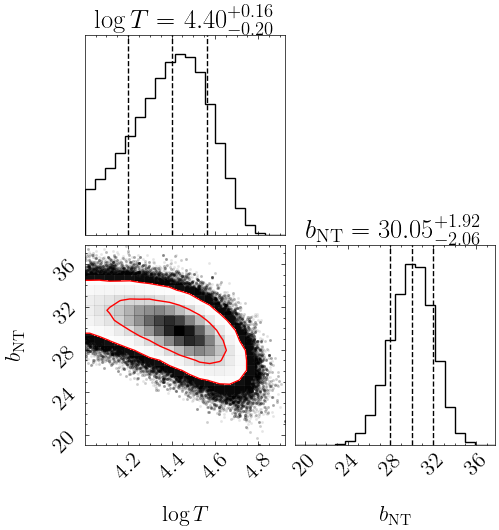

In [56]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [57]:
np.percentile(flat_samples['logT'], 100*(1-cdf_3sig)), np.percentile(flat_samples['logT'], 100*cdf_3sig)

(4.002625110437029, 4.791442167455569)

### c1H

In [58]:
b_list = [[
          ['CIV', 'C', 33, 5],
          ['OIV', 'O', 30, 2],
          ['OVI', 'O', 32, 3]
          ]]

In [59]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(200, 2)
nwalkers, ndim = pos.shape

In [60]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [61]:
sampler.run_mcmc(pos, 5000, progress=True)

100%|██████████████████████████████████████████████████████| 5000/5000 [00:12<00:00, 400.73it/s]


State([[ 5.97151541  4.51791222]
 [ 5.6397024  19.54580103]
 [ 4.99870174 28.38913004]
 [ 5.82000051 17.88944415]
 [ 4.81405046 28.65208579]
 [ 5.93039058  4.73105034]
 [ 5.35724874 25.5223347 ]
 [ 5.8890873  14.15134813]
 [ 5.30348053 26.63696957]
 [ 5.93977954  0.47752284]
 [ 5.69730407 18.93158581]
 [ 5.77917476 13.15292701]
 [ 5.90623753  9.22780384]
 [ 5.82670464 12.09367023]
 [ 5.55324975 23.81331668]
 [ 4.53763603 32.47972571]
 [ 5.82912582 14.53919201]
 [ 5.37959715 25.03292016]
 [ 5.85698342 13.33364738]
 [ 5.99480614  2.61238246]
 [ 5.89838983  2.78258329]
 [ 5.8033777  14.63590331]
 [ 5.63562289 14.34678505]
 [ 5.55356902 26.83405557]
 [ 5.58627033 26.18931667]
 [ 5.71355377 18.73751996]
 [ 5.59704502 20.13930953]
 [ 5.1490369  25.45425002]
 [ 4.63690735 32.44227478]
 [ 5.71821146 22.87852158]
 [ 5.75124741 17.36911311]
 [ 5.70529519 15.96147173]
 [ 5.8894104   7.60699751]
 [ 5.75719021 16.37080618]
 [ 5.90214138 15.26964755]
 [ 5.62780066 23.34446045]
 [ 5.91755652 14.43416

In [62]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=500, flat=True), 
                                columns=['logT', 'b_NT'])

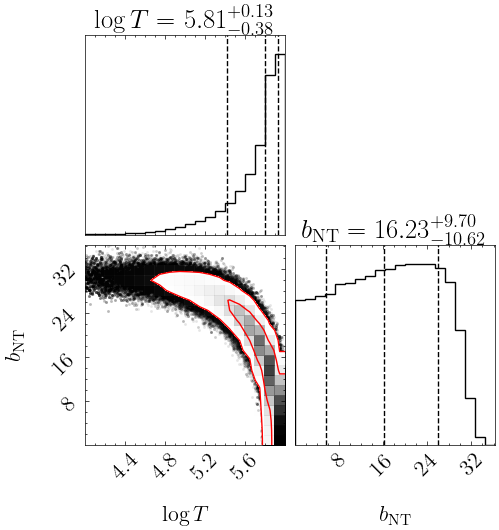

In [63]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

(array([ 49520.,  58197.,  64633.,  71416.,  79429.,  90848., 109897.,
        144707., 150593.,  80760.]),
 array([ 10003.02477024, 109002.21647934, 208001.40818843, 307000.59989752,
        405999.79160661, 504998.98331571, 603998.1750248 , 702997.36673389,
        801996.55844299, 900995.75015208, 999994.94186117]),
 <BarContainer object of 10 artists>)

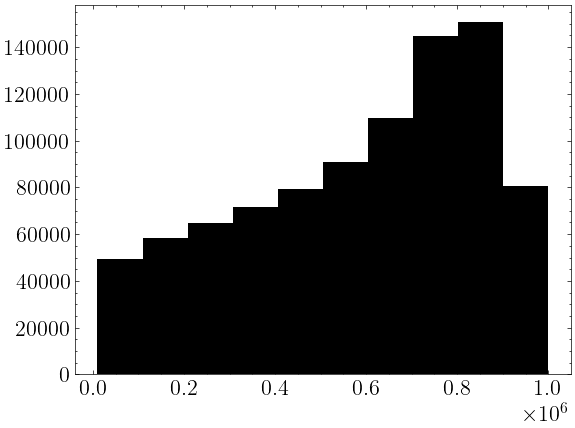

In [64]:
plt.hist(10**flat_samples['logT'])

In [65]:
np.percentile(flat_samples['logT'], 100*(1-cdf_3sig)), np.percentile(flat_samples['logT'], 100*cdf_3sig)

(4.097293221923655, 5.998850669650965)

In [66]:
np.percentile(flat_samples['b_NT'], 100*cdf_3sig)

33.22714675163305

# z=1.04

## c1

In [57]:
b_list = [[['HI', 'H', 19, 1],
          ['CIV', 'C', 6.8, 0.2]]]

In [58]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(200, 2)
nwalkers, ndim = pos.shape

In [59]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [60]:
sampler.run_mcmc(pos, 5000, progress=True)

100%|██████████████████████████████████████████████████████| 5000/5000 [00:11<00:00, 440.23it/s]


State([[4.35402204 3.91548534]
 [4.39683043 2.95704924]
 [4.22899867 4.80925676]
 [4.31702249 3.63562758]
 [4.29644435 4.41738229]
 [4.32099729 3.84930609]
 [4.34959776 3.66505306]
 [4.34658033 3.72944646]
 [4.37103873 4.13895687]
 [4.3357664  3.98874455]
 [4.27233366 4.4898332 ]
 [4.34943791 4.17429052]
 [4.33564482 3.84286168]
 [4.40195915 2.94843407]
 [4.36178322 3.56270176]
 [4.28927401 4.3875114 ]
 [4.25881834 4.98819641]
 [4.27339746 4.55061832]
 [4.28561973 4.47763779]
 [4.34809886 4.29060116]
 [4.31760033 4.25034273]
 [4.32099729 2.95596055]
 [4.30293655 4.3289969 ]
 [4.39965199 3.6893804 ]
 [4.39026265 3.86530504]
 [4.35986155 3.56776107]
 [4.39563246 3.27276112]
 [4.30388428 4.22841477]
 [4.27522664 4.71809552]
 [4.27935847 4.01139148]
 [4.28227541 4.43588024]
 [4.22821904 4.72062373]
 [4.29299121 3.9255795 ]
 [4.29215645 4.28672775]
 [4.2300555  4.25032991]
 [4.40293668 3.33492838]
 [4.3475835  3.22579746]
 [4.31853379 4.00239439]
 [4.39015187 2.93527909]
 [4.36061639 3.7279

In [61]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=500, flat=True), 
                                columns=['logT', 'b_NT'])

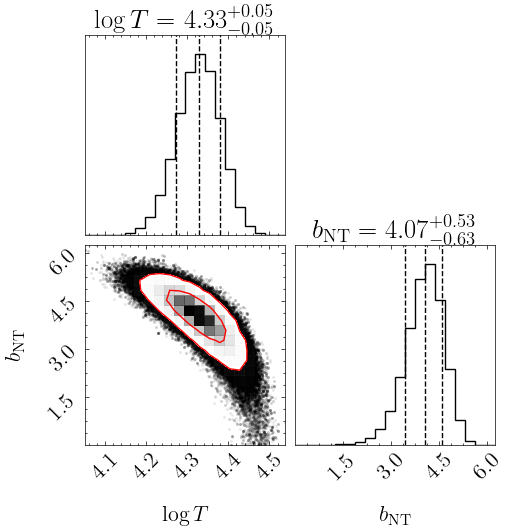

In [62]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

## c2

In [63]:
b_list = [[['HI', 'H', 10, 3],
          ['CIV', 'C', 6.1, 0.4]]]

In [64]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(200, 2)
nwalkers, ndim = pos.shape

In [65]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [66]:
sampler.run_mcmc(pos, 5000, progress=True)

100%|██████████████████████████████████████████████████████| 5000/5000 [00:10<00:00, 475.08it/s]


State([[4.05660769 4.91766333]
 [4.14228327 4.7970147 ]
 [4.21951257 4.27702353]
 [4.01820903 5.26870724]
 [4.19778733 3.66087817]
 [4.07781639 3.71335452]
 [4.10530923 4.47937057]
 [4.05364302 4.57059456]
 [4.18161314 4.78093791]
 [4.08719249 3.85820219]
 [4.00560173 4.71472788]
 [4.02025719 4.94896444]
 [4.08964053 4.89930312]
 [4.18214027 4.7407189 ]
 [4.00532222 4.61138562]
 [4.15662933 4.39835139]
 [4.19600891 3.58211618]
 [4.01712364 4.74728502]
 [4.14986582 4.49490708]
 [4.14950539 4.52422479]
 [4.17799184 3.36965614]
 [4.01591144 4.56888545]
 [4.22608078 3.99022173]
 [4.10728635 3.50325087]
 [4.01760038 5.78807087]
 [4.24121735 3.90340546]
 [4.15995435 3.03083533]
 [4.0195793  4.49394215]
 [4.16034996 4.38805814]
 [4.15456997 4.45056228]
 [4.07991779 4.44517823]
 [4.04690091 5.08962697]
 [4.29389443 1.45861676]
 [4.07126779 5.26610771]
 [4.25655756 3.58716429]
 [4.30822271 0.89593391]
 [4.03029305 5.55997588]
 [4.14439038 4.28603601]
 [4.15948381 3.75498729]
 [4.09648431 4.7061

In [67]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=500, flat=True), 
                                columns=['logT', 'b_NT'])

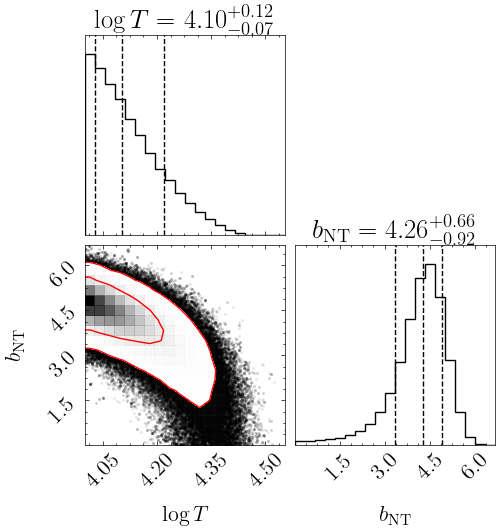

In [68]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [70]:
np.percentile(flat_samples['logT'], 100*cdf_3sig)

4.430811342347855

## c3

In [71]:
b_list = [[['HI', 'H', 14, 4],
          ['CIV', 'C', 10, 1]]]

In [72]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(200, 2)
nwalkers, ndim = pos.shape

In [73]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [74]:
sampler.run_mcmc(pos, 5000, progress=True)

100%|██████████████████████████████████████████████████████| 5000/5000 [00:11<00:00, 445.78it/s]


State([[ 4.41629691  9.21306233]
 [ 4.37690969  7.10682749]
 [ 4.05267766  8.54075288]
 [ 4.01734324  7.88899539]
 [ 4.22845809  8.29579871]
 [ 4.43453436  7.61070076]
 [ 4.0837003   9.16559805]
 [ 4.01083449 10.4550257 ]
 [ 4.27449245  8.69039741]
 [ 4.23116242  8.04192298]
 [ 4.30848619  7.58206887]
 [ 4.11459513  8.94293509]
 [ 4.13705256  8.424258  ]
 [ 4.13945432  7.1905754 ]
 [ 4.06153594  9.43473789]
 [ 4.09930934  9.5966888 ]
 [ 4.03019491  8.63115087]
 [ 4.29426307  6.39911777]
 [ 4.19171747  8.42173887]
 [ 4.2395158   9.23218965]
 [ 4.25647033  8.75816994]
 [ 4.37040238  5.70683335]
 [ 4.16247303  8.93130652]
 [ 4.22248516  8.8748262 ]
 [ 4.38725278 10.08325549]
 [ 4.17147952  5.55637782]
 [ 4.32709176  6.97765476]
 [ 4.25827134  7.99138769]
 [ 4.45069646  7.24694188]
 [ 4.19659685  9.62641468]
 [ 4.27253674 10.39359718]
 [ 4.08264268  7.27779366]
 [ 4.31196147  7.89604045]
 [ 4.06038065  9.10653382]
 [ 4.46223977  8.64792371]
 [ 4.47091922  9.48340767]
 [ 4.1879957   6.32096

In [75]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=500, flat=True), 
                                columns=['logT', 'b_NT'])

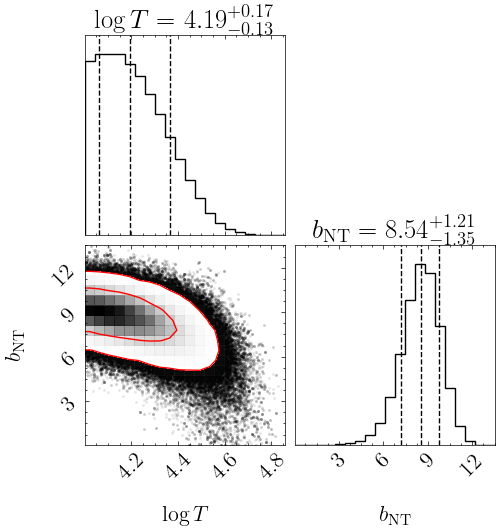

In [76]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [78]:
np.percentile(flat_samples['logT'], 100*cdf_3sig)

4.675907943543086

## c4

In [79]:
b_list = [[['HI', 'H', 22, 5],
          ['CIV', 'C', 8.2, 0.6]]]

In [80]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(200, 2)
nwalkers, ndim = pos.shape

In [81]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [82]:
sampler.run_mcmc(pos, 5000, progress=True)

100%|██████████████████████████████████████████████████████| 5000/5000 [00:10<00:00, 469.19it/s]


State([[4.57995218 5.50907572]
 [4.03186753 6.78289019]
 [4.57873006 1.84587854]
 [4.3047931  5.35245389]
 [4.58246109 2.18738352]
 [4.42804895 4.45047071]
 [4.64204647 4.1021623 ]
 [4.55034826 1.63573013]
 [4.51360999 4.43882122]
 [4.55459814 3.82478375]
 [4.48024705 4.64981834]
 [4.49063428 5.20137459]
 [4.43149559 5.55749785]
 [4.39610337 5.78801866]
 [4.32848998 5.23391332]
 [4.64879671 2.30936253]
 [4.21604188 7.51303019]
 [4.56292863 2.7812803 ]
 [4.36720647 7.24363347]
 [4.55692082 4.26941309]
 [4.52057713 5.40509629]
 [4.6583749  3.43885613]
 [4.6229483  3.96546661]
 [4.43861214 4.91920639]
 [4.74095987 2.16897364]
 [4.27174974 6.33327306]
 [4.05675302 7.06565286]
 [4.48151418 5.7935819 ]
 [4.68471826 3.32645515]
 [4.54433889 4.61580852]
 [4.32270365 6.73159851]
 [4.09527602 7.38666834]
 [4.45113057 3.97096083]
 [4.47048182 5.08769203]
 [4.54184415 4.18151553]
 [4.10274271 6.98278208]
 [4.68435294 4.72372367]
 [4.57726773 3.5816978 ]
 [4.6546169  1.39809949]
 [4.51962393 4.2233

In [85]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=500, flat=True), 
                                columns=['logT', 'b_NT'])

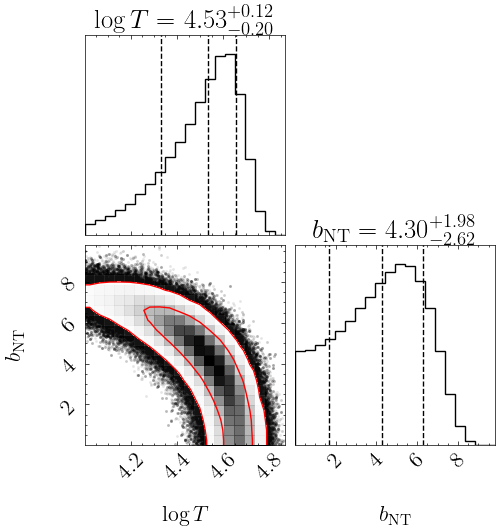

In [86]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [87]:
np.percentile(flat_samples['b_NT'], 100*cdf_3sig)

8.521720983525503

# z=1.09

## c1

### c1L

In [35]:
b_list = [[['HI', 'H', 22, 2],
          ['CIV', 'C', 18.2, 0.3]]]

In [36]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(200, 2)
nwalkers, ndim = pos.shape

In [37]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [38]:
sampler.run_mcmc(pos, 5000, progress=True)

100%|██████████████████████████████████████████████████████| 5000/5000 [00:10<00:00, 495.29it/s]


State([[ 4.14090632 18.17310156]
 [ 4.0248794  17.47223599]
 [ 4.11271919 18.52431382]
 [ 4.00349144 18.17017114]
 [ 4.26666527 18.09379649]
 [ 4.20916024 17.21149655]
 [ 4.23643996 17.27298028]
 [ 4.04000614 17.7177123 ]
 [ 4.1532849  17.68519232]
 [ 4.33331949 17.00416955]
 [ 4.11231    17.65935084]
 [ 4.26346956 17.58190277]
 [ 4.18403766 17.54822682]
 [ 4.23150137 17.5659307 ]
 [ 4.00266281 17.73635111]
 [ 4.39141511 17.58976757]
 [ 4.22194807 17.93204614]
 [ 4.19426133 17.74862433]
 [ 4.18445717 17.55531495]
 [ 4.1625847  17.12438802]
 [ 4.23829865 16.960717  ]
 [ 4.03408989 17.94399419]
 [ 4.15199299 17.87285901]
 [ 4.31606367 17.70227594]
 [ 4.10307421 17.5107645 ]
 [ 4.3667209  17.40901425]
 [ 4.0696962  17.06867367]
 [ 4.18255546 17.4141847 ]
 [ 4.01450018 17.15034989]
 [ 4.03038921 17.70382214]
 [ 4.07019673 17.94969195]
 [ 4.10156818 17.73589216]
 [ 4.22641235 17.10581399]
 [ 4.05755622 17.73286822]
 [ 4.39670311 17.61906215]
 [ 4.05466836 18.46923015]
 [ 4.16543328 18.12795

In [39]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=500, flat=True), 
                                columns=['logT', 'b_NT'])

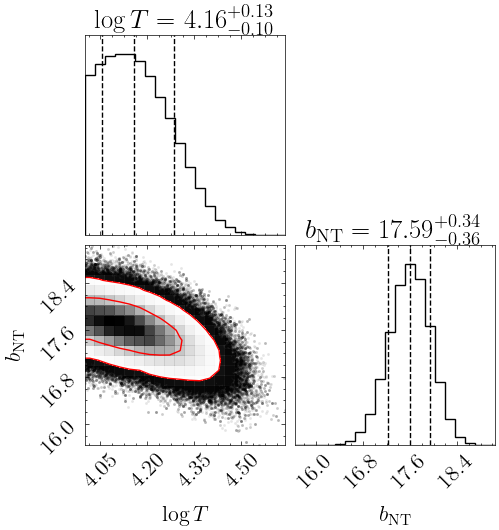

In [40]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [41]:
np.percentile(flat_samples['logT'], 100*cdf_3sig)

4.507004448962375

### c1H

In [42]:
b_list = [[['OIV', 'O', 23, 1],
          ['OV', 'O', 26, 2]]]

In [43]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(200, 2)
nwalkers, ndim = pos.shape

In [44]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [45]:
sampler.run_mcmc(pos, 5000, progress=True)

100%|██████████████████████████████████████████████████████| 5000/5000 [00:10<00:00, 475.76it/s]


State([[ 5.61610843 12.75869868]
 [ 5.6922892   2.82441017]
 [ 5.50336712 16.36398195]
 [ 5.70717288  9.24627965]
 [ 5.71227769  2.84422526]
 [ 5.63485218  6.31247905]
 [ 5.68399541  3.86520806]
 [ 5.43340357 16.80016637]
 [ 4.79550856 22.2317052 ]
 [ 5.70288576 11.5702901 ]
 [ 5.05687559 20.21634232]
 [ 5.04376727 21.91722835]
 [ 5.50271029 14.96770536]
 [ 5.62228398 11.52067901]
 [ 5.52916888 14.74192844]
 [ 5.76085817  6.22490596]
 [ 4.97120097 22.31391932]
 [ 5.68760967 10.13909412]
 [ 5.71336863  0.84695051]
 [ 4.80338117 22.58091441]
 [ 5.72686486  5.14376825]
 [ 5.62883069 11.18433701]
 [ 5.7465849   1.35274113]
 [ 5.53908581 16.83587089]
 [ 5.67397771 10.28809625]
 [ 5.53096238 14.77969354]
 [ 5.67585034 10.60239614]
 [ 5.59002726 10.22152164]
 [ 5.6081101   6.91582494]
 [ 5.68879762  3.04200856]
 [ 4.17026331 21.84389842]
 [ 5.34988804 18.67866953]
 [ 5.41910168 15.08819295]
 [ 5.60732032 10.89103885]
 [ 5.05933863 21.36373023]
 [ 5.62815451 10.79470743]
 [ 4.42899312 21.48640

In [46]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=500, flat=True), 
                                columns=['logT', 'b_NT'])

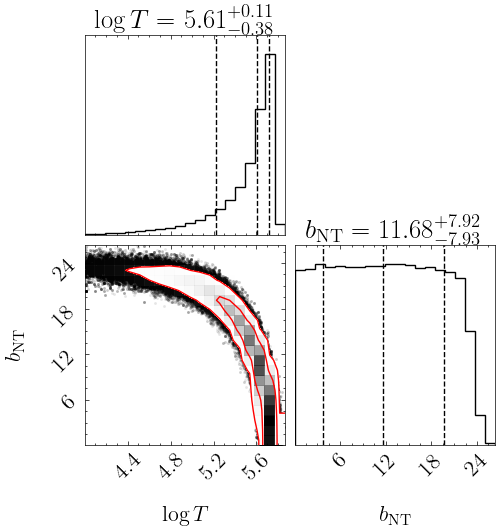

In [47]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [50]:
np.percentile(flat_samples['logT'], 100*(1-cdf_3sig)), np.percentile(flat_samples['logT'], 100*cdf_3sig)

(4.0547398229694105, 5.805229570595703)

In [49]:
np.percentile(flat_samples['b_NT'], 100*cdf_3sig)

24.71190794328449

# z=1.16

## c1

In [115]:
b_list = [[['HI', 'H', 19, 3],
          ['HeI', 'He', 12, 1],
          ['CIV', 'C', 11.0, 0.4],
          ['OIII', 'O', 14, 3],
          ['OIV', 'O', 16, 2],
          ['OV', 'O', 10, 3],
          ['SiIII', 'Si', 11, 2]]]

In [116]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(200, 2)
nwalkers, ndim = pos.shape

In [117]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [118]:
sampler.run_mcmc(pos, 5000, progress=True)

100%|██████████████████████████████████████████████████████| 5000/5000 [00:21<00:00, 231.61it/s]


State([[ 4.28430837  9.77439778]
 [ 4.37935419  9.53742717]
 [ 4.0540846  11.00889951]
 [ 4.05610687 10.61490078]
 [ 4.22485899  9.66457088]
 [ 4.25775548  9.08766094]
 [ 4.06504637 10.71167886]
 [ 4.06465362 10.72175377]
 [ 4.08688677 10.7765421 ]
 [ 4.15887955 10.41684353]
 [ 4.05720472 10.54067753]
 [ 4.25536817  9.89875255]
 [ 4.02817939 10.44495121]
 [ 4.00343273 10.75004473]
 [ 4.24386896 10.09157475]
 [ 4.24715981  9.91901531]
 [ 4.11992563 10.87486458]
 [ 4.26146129 10.26230367]
 [ 4.17920468 10.37195807]
 [ 4.07146742 10.10044263]
 [ 4.24733966 10.1460022 ]
 [ 4.01935945 10.17022601]
 [ 4.02619362  9.64066163]
 [ 4.44837638  8.80696496]
 [ 4.01335402 10.1630203 ]
 [ 4.01430961 10.89945017]
 [ 4.25512983  9.75081323]
 [ 4.01252619  9.73815098]
 [ 4.14084957 10.08829621]
 [ 4.16860469 10.31289878]
 [ 4.24539052  9.90769125]
 [ 4.24763526 10.22682908]
 [ 4.25436651 10.4911867 ]
 [ 4.19259962 10.51547341]
 [ 4.25726996  9.9263729 ]
 [ 4.50521592  9.17334064]
 [ 4.01907027 10.57493

In [119]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=500, flat=True), 
                                columns=['logT', 'b_NT'])

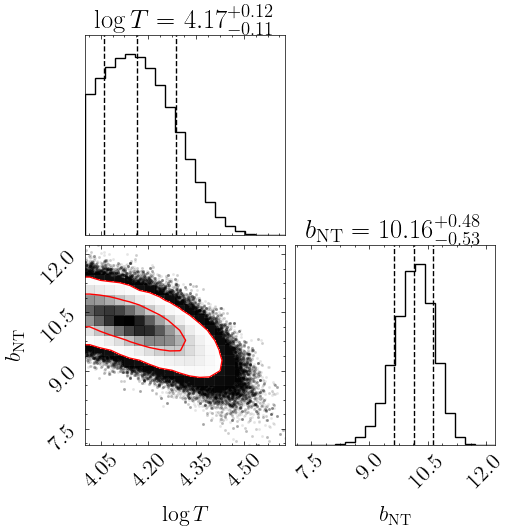

In [120]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [121]:
np.percentile(flat_samples['logT'], 100*cdf_3sig)

4.502269625199734

## c2

In [122]:
b_list = [[['HI', 'H', 32, 3],
          ['CIV', 'C', 27, 3],
          ['OIV', 'O', 27, 7],
          ['OV', 'O', 28, 3]]]
          #['OVI', 'O', 45, 22]]]

In [123]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(200, 2)
nwalkers, ndim = pos.shape

In [124]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [125]:
sampler.run_mcmc(pos, 5000, progress=True)

100%|██████████████████████████████████████████████████████| 5000/5000 [00:15<00:00, 318.15it/s]


State([[ 4.23958893 26.18567165]
 [ 4.64240573 25.41552878]
 [ 4.70517034 23.18018569]
 [ 4.60064196 26.40558317]
 [ 4.32810448 28.34753685]
 [ 4.31186567 26.20014339]
 [ 4.27218028 28.80621945]
 [ 4.37633931 28.85215864]
 [ 4.49767737 26.06538883]
 [ 4.47414904 24.27097782]
 [ 4.42133113 26.16260119]
 [ 4.1321855  28.22277036]
 [ 4.40630173 26.32939063]
 [ 4.07435395 29.00653635]
 [ 4.28271425 27.0892938 ]
 [ 4.39344059 26.97883617]
 [ 4.65007124 21.30458014]
 [ 4.42032113 28.65582225]
 [ 4.48827277 26.14475016]
 [ 4.51507712 26.95667196]
 [ 4.2511868  25.03401007]
 [ 4.78684408 23.11393313]
 [ 4.55706275 24.14157337]
 [ 4.49334371 27.38658464]
 [ 4.72853648 26.89308904]
 [ 4.19850946 24.06568182]
 [ 4.21615386 24.83916086]
 [ 4.09211006 26.88519632]
 [ 4.16085539 26.84632557]
 [ 4.29833925 24.81608736]
 [ 4.43956402 25.8222067 ]
 [ 4.49536807 26.99570706]
 [ 4.08416645 27.31198286]
 [ 4.33866152 26.87912431]
 [ 4.25545566 27.09335253]
 [ 4.23688552 22.58224495]
 [ 4.17257064 24.35608

In [126]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=500, flat=True), 
                                columns=['logT', 'b_NT'])

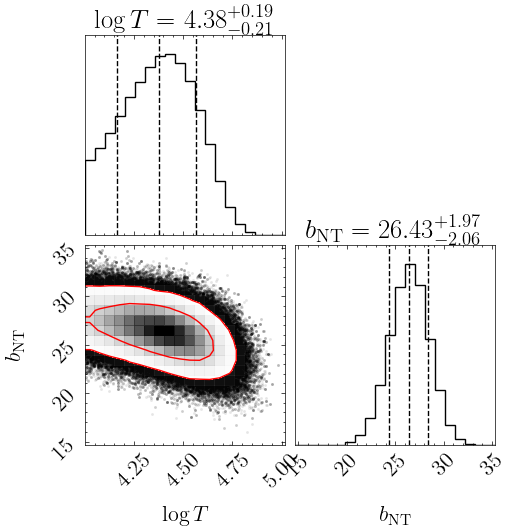

In [127]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [128]:
np.percentile(flat_samples['logT'], 100*cdf_3sig)

4.83322101880488

# z=1.22

## c1

In [129]:
b_list = [[['HI', 'H', 25, 4],
          ['CIV', 'C', 17, 3],
          ['OIV', 'O', 30, 4],
          ['OV', 'O', 31, 2]]]

In [130]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(200, 2)
nwalkers, ndim = pos.shape

In [131]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [132]:
sampler.run_mcmc(pos, 5000, progress=True)

100%|██████████████████████████████████████████████████████| 5000/5000 [00:14<00:00, 334.03it/s]


State([[ 4.38856865 26.43070521]
 [ 4.44036564 24.43865932]
 [ 4.0713123  24.68272679]
 [ 4.20173986 24.46333578]
 [ 4.41645428 24.92766691]
 [ 4.19878681 28.63726713]
 [ 4.32871101 26.62351425]
 [ 4.23837944 23.67297244]
 [ 4.16795132 26.61330147]
 [ 4.0888418  27.06891339]
 [ 4.2341048  25.13978698]
 [ 4.26638284 23.71465077]
 [ 4.26955054 26.90456969]
 [ 4.11770905 24.7854074 ]
 [ 4.37759942 28.35999508]
 [ 4.30283398 25.11885372]
 [ 4.01038747 26.59085506]
 [ 4.38355644 25.85574607]
 [ 4.05952961 26.94665246]
 [ 4.30878281 27.70690005]
 [ 4.20987666 25.07608256]
 [ 4.01382845 23.82909543]
 [ 4.03934797 26.24687942]
 [ 4.38835144 28.58399932]
 [ 4.04015915 29.53056228]
 [ 4.08216273 24.41013659]
 [ 4.23429786 26.03811755]
 [ 4.1090789  25.97143371]
 [ 4.12879687 24.79899554]
 [ 4.2531351  27.14491879]
 [ 4.13479995 26.76549913]
 [ 4.03080195 27.8510663 ]
 [ 4.25552724 23.48489017]
 [ 4.17015324 27.46411605]
 [ 4.01639578 28.42793395]
 [ 4.55844791 25.78426371]
 [ 4.28611008 26.41180

In [133]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=500, flat=True), 
                                columns=['logT', 'b_NT'])

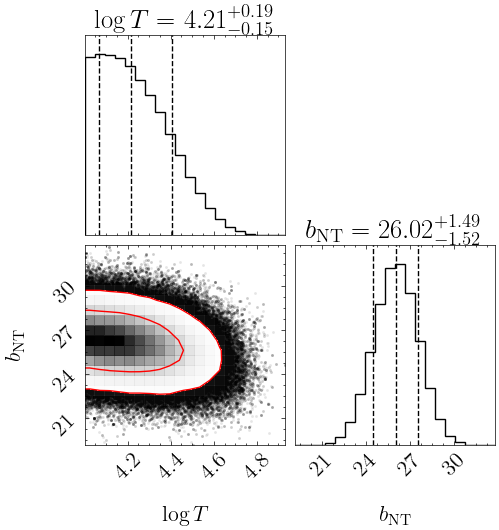

In [134]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [135]:
np.percentile(flat_samples['logT'], 100*cdf_3sig)

4.736345157295673

# z=1.26

## c1

In [67]:
b_list = [[['HI', 'H', 22, 2],
          ['CIV', 'C', 6.6, 0.6]
          ]]

In [68]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(200, 2)
nwalkers, ndim = pos.shape

In [69]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [70]:
sampler.run_mcmc(pos, 5000, progress=True)

100%|██████████████████████████████████████████████████████| 5000/5000 [00:10<00:00, 469.73it/s]


State([[4.468514   3.26040433]
 [4.41093077 1.32275714]
 [4.3400377  3.73550531]
 [4.48732769 1.08235554]
 [4.42198375 0.94027029]
 [4.48600509 1.32187042]
 [4.5039234  1.99457459]
 [4.49587662 1.40903408]
 [4.42773745 3.31862709]
 [4.42408688 1.54479832]
 [4.57166999 1.02009172]
 [4.41233665 1.64556624]
 [4.3844988  2.44893522]
 [4.4922497  0.43347616]
 [4.4564448  3.28192506]
 [4.37074252 0.27138033]
 [4.4172393  1.92968252]
 [4.48271054 0.67689411]
 [4.34232058 1.59018248]
 [4.43850742 3.21360046]
 [4.53061255 1.23613709]
 [4.55113586 0.10851436]
 [4.51688114 2.77166971]
 [4.55803777 0.56705564]
 [4.48892964 0.43624373]
 [4.45367869 0.62043681]
 [4.54646854 2.30388065]
 [4.49378065 1.21756973]
 [4.58557624 2.35983942]
 [4.43043384 3.42202493]
 [4.45682063 2.16874551]
 [4.52108939 2.27532668]
 [4.44893265 2.10122559]
 [4.46980035 1.01917012]
 [4.53893354 2.08424562]
 [4.44586361 3.71625193]
 [4.61770179 2.20391971]
 [4.43101114 3.02292464]
 [4.33007387 2.9001334 ]
 [4.55783992 2.5260

In [71]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=500, flat=True), 
                                columns=['logT', 'b_NT'])

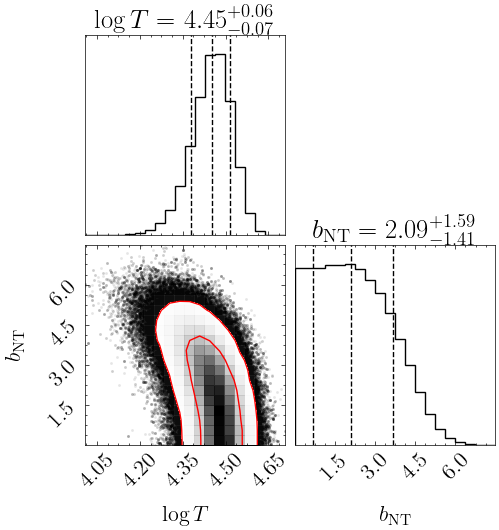

In [72]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [73]:
np.percentile(flat_samples['logT'], 100*(1-cdf_3sig)), np.percentile(flat_samples['logT'], 100*cdf_3sig)

(4.173639557659739, 4.625459421970127)

In [75]:
np.percentile(flat_samples['b_NT'], 100*cdf_3sig)

6.117470483638951

# z=1.27

## c1

### c1L

In [76]:
b_list = [[['HI', 'H', 24, 3],
          ['OIII', 'O', 12, 1],]]

In [77]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(200, 2)
nwalkers, ndim = pos.shape

In [78]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [79]:
sampler.run_mcmc(pos, 5000, progress=True)

100%|██████████████████████████████████████████████████████| 5000/5000 [00:11<00:00, 432.01it/s]


State([[ 4.38293599 12.26069553]
 [ 4.58055526  9.49515515]
 [ 4.620567    9.22810194]
 [ 4.53037236 10.90184221]
 [ 4.22668615  9.78035837]
 [ 4.41574986 10.26070714]
 [ 4.45329195 10.58863932]
 [ 4.64565033  9.96905373]
 [ 4.53597626 10.50225121]
 [ 4.56485363  9.25422102]
 [ 4.62022124  9.40826424]
 [ 4.34419747  9.86536666]
 [ 4.53435321  9.40810653]
 [ 4.25196541 10.2226895 ]
 [ 4.57511662  8.5454934 ]
 [ 4.55111628 12.94355366]
 [ 4.43495762 10.26466479]
 [ 4.22417428 12.49975153]
 [ 4.53224122  9.7153161 ]
 [ 4.43748803 11.23218578]
 [ 4.50015006 10.77394623]
 [ 4.56267137 11.064322  ]
 [ 4.44441487 10.85619641]
 [ 4.24478711 12.10497902]
 [ 4.29459652 10.61360174]
 [ 4.56292592 10.63530925]
 [ 4.61464399 10.72317398]
 [ 4.51526254 11.60784143]
 [ 4.03898929 13.98898748]
 [ 4.29807415  9.84312927]
 [ 4.23475808 11.36810475]
 [ 4.49551803 11.29444865]
 [ 4.47508497  9.97874108]
 [ 4.51890132 10.15474282]
 [ 4.68317132  8.44740443]
 [ 4.27778432 10.41323078]
 [ 4.26165532 13.88273

In [80]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=500, flat=True), 
                                columns=['logT', 'b_NT'])

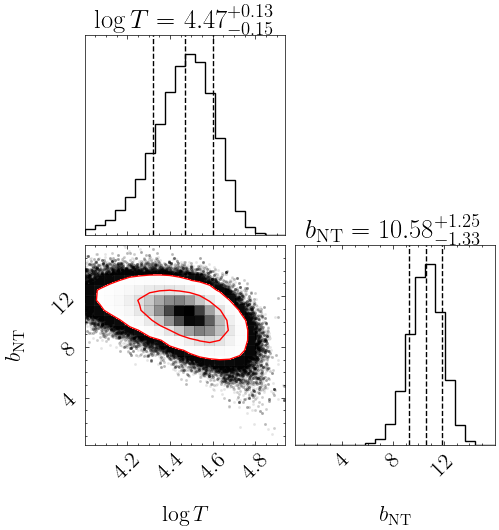

In [81]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [82]:
np.percentile(flat_samples['logT'], 100*(1-cdf_3sig)), np.percentile(flat_samples['logT'], 100*cdf_3sig)

(4.0140015546901555, 4.806590692671808)

### c1H

In [91]:
b_list = [[['CIV', 'C', 11.1, 0.2],
           ['NIV', 'N', 12, 5],
          ['OIV', 'O', 12, 1],
          ['OVI', 'O', 17, 2]]]

In [92]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(200, 2)
nwalkers, ndim = pos.shape

In [93]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [94]:
sampler.run_mcmc(pos, 5000, progress=True)

100%|██████████████████████████████████████████████████████| 5000/5000 [00:14<00:00, 356.56it/s]


State([[ 4.16879567 10.70678377]
 [ 4.30886223  9.60826865]
 [ 4.22887577 10.27596254]
 [ 4.10737083 10.26230285]
 [ 4.51358307  8.83370254]
 [ 4.21175742  9.98272111]
 [ 4.23222221  9.96427172]
 [ 4.49283601  9.36908743]
 [ 4.4721262   9.41150092]
 [ 4.08094321 10.63112389]
 [ 4.26208907 10.11312978]
 [ 4.30242709  9.67532461]
 [ 4.17773183 10.17213829]
 [ 4.55151232  8.89440539]
 [ 4.89791425  3.98291959]
 [ 4.52154676  8.56546315]
 [ 4.59233722  7.99518341]
 [ 4.78413356  5.80628953]
 [ 4.23119617 10.3562395 ]
 [ 4.8285101   6.2559296 ]
 [ 4.32779001  9.89198262]
 [ 4.5532394   9.03120799]
 [ 4.58997033  8.38706913]
 [ 4.41509928  9.83885559]
 [ 4.63020985  8.03597418]
 [ 4.6019954   8.41587017]
 [ 4.53307352  9.06788173]
 [ 4.22508623 10.25233955]
 [ 4.45423055  8.6008722 ]
 [ 4.39060894  9.74043164]
 [ 4.43400274  9.36849485]
 [ 4.24194716 10.02547573]
 [ 4.63093997  7.77710753]
 [ 4.66390859  8.00896818]
 [ 4.97524965  1.55360565]
 [ 4.40900623  9.92439619]
 [ 4.4257677   9.69663

In [95]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=500, flat=True), 
                                columns=['logT', 'b_NT'])

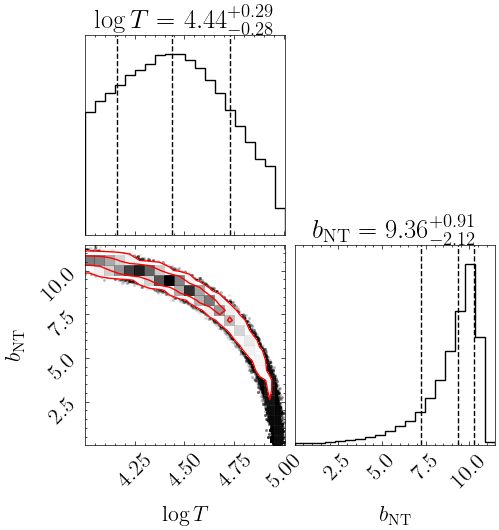

In [96]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [97]:
np.percentile(flat_samples['logT'], 100*(1-cdf_3sig)), np.percentile(flat_samples['logT'], 100*cdf_3sig)

(4.001337187864826, 4.975817534594172)

In [98]:
np.percentile(flat_samples['b_NT'], 100*cdf_3sig)

10.959280000983236

# z=1.27, c2

In [158]:
b_list = [[['HI', 'H', 37, 10],
          ['CIV', 'C', 9.8, 0.3],
          ['OIV', 'O', 10, 1],
          ['OVI', 'O', 14, 4]]]

In [159]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(200, 2)
nwalkers, ndim = pos.shape

In [160]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [161]:
sampler.run_mcmc(pos, 5000, progress=True)

100%|██████████████████████████████████████████████████████| 5000/5000 [00:14<00:00, 338.96it/s]


State([[4.31267286 8.08741486]
 [4.65032129 6.6121496 ]
 [4.83390437 0.90956186]
 [4.63840771 6.53741572]
 [4.67316491 5.51965978]
 [4.44125786 6.84180826]
 [4.85440895 2.20374697]
 [4.71307042 5.04363817]
 [4.66942226 5.22851717]
 [4.81906669 2.2873574 ]
 [4.62747509 5.29157554]
 [4.85102918 3.56161066]
 [4.52335878 7.291793  ]
 [4.31188186 8.1782975 ]
 [4.58368615 6.36217132]
 [4.84930892 1.15763317]
 [4.46837715 7.81258419]
 [4.82924239 1.81604025]
 [4.44789467 7.29599408]
 [4.64746178 5.91346246]
 [4.85967987 0.68253109]
 [4.61356269 7.05243564]
 [4.78342758 4.79900084]
 [4.8486267  2.8483745 ]
 [4.38184417 8.47192426]
 [4.4193403  7.79575266]
 [4.63914767 6.59188444]
 [4.36857435 7.601593  ]
 [4.74743464 5.03947003]
 [4.67417175 4.67986669]
 [4.74128612 5.09826411]
 [4.72576922 4.83923591]
 [4.78418254 3.28861034]
 [4.63642012 5.77651563]
 [4.85995721 0.50418609]
 [4.80623993 4.03382859]
 [4.58708384 7.3381358 ]
 [4.73702861 4.96431413]
 [4.83278533 2.61324631]
 [4.8801574  0.2823

In [162]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=500, flat=True), 
                                columns=['logT', 'b_NT'])

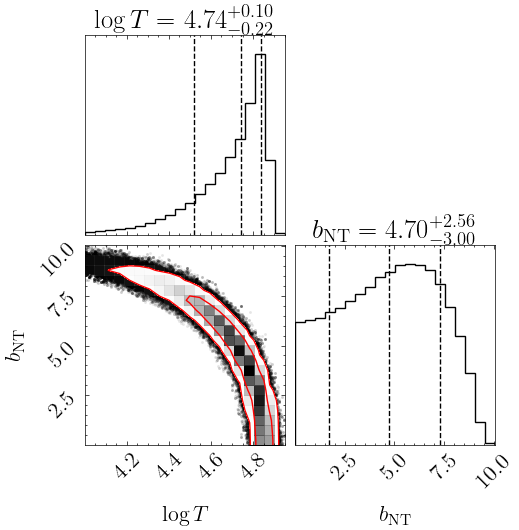

In [163]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [164]:
np.percentile(flat_samples['b_NT'], 100*cdf_3sig)

9.427140721422536

# DRAFT

## z=0.72

In [69]:
b_list = [[['HI', 'H', 25.6, 0.4],
          ['CIII', 'C', 15, 4],
          ['OIII', 'O', 12, 2]]]

In [70]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(200, 2)
nwalkers, ndim = pos.shape

In [71]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [72]:
sampler.run_mcmc(pos, 5000, progress=True)

100%|██████████████████████████████████████| 5000/5000 [00:13<00:00, 378.65it/s]


State([[ 4.5384403   8.09929585]
 [ 4.47312911 12.56506458]
 [ 4.51935019  9.9915456 ]
 [ 4.43163142 15.65060414]
 [ 4.52375086  9.37540148]
 [ 4.54954478  6.62458899]
 [ 4.52685679 10.13970275]
 [ 4.42873199 14.08212653]
 [ 4.50605638 12.29829318]
 [ 4.50825934 10.95642096]
 [ 4.52653629 10.0437353 ]
 [ 4.43088461 14.06331714]
 [ 4.52991303 10.05491318]
 [ 4.5366154   8.2728032 ]
 [ 4.57220497  8.25733952]
 [ 4.47898707 12.46445221]
 [ 4.57009848  8.66609242]
 [ 4.50306259 11.53717785]
 [ 4.36597978 15.86877089]
 [ 4.56793488  9.68422604]
 [ 4.45187513 13.86462879]
 [ 4.56351901  5.3446461 ]
 [ 4.59466794  3.46409942]
 [ 4.53785633  9.65510504]
 [ 4.55211141  8.05027689]
 [ 4.49100075 11.93868292]
 [ 4.54138785 10.3322841 ]
 [ 4.54959999  9.2107803 ]
 [ 4.42833962 14.57471485]
 [ 4.51295023 12.04145711]
 [ 4.59385652  7.83400509]
 [ 4.46092935 12.78548227]
 [ 4.5263072  12.37414796]
 [ 4.48133168 13.77105522]
 [ 4.49751563 10.66109777]
 [ 4.53237196  9.36835803]
 [ 4.53007861 10.24665

In [73]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=500, flat=True), 
                                columns=['logT', 'b_NT'])

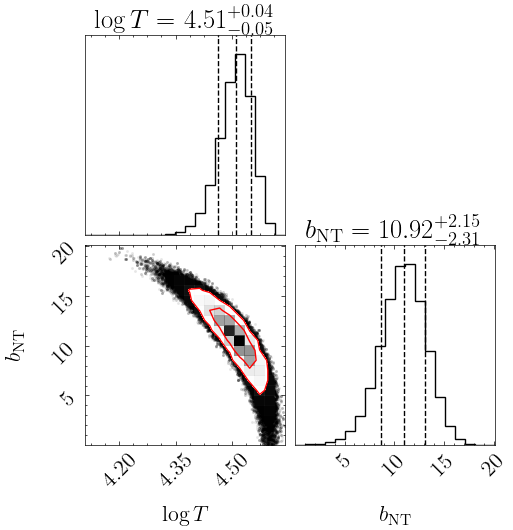

In [74]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

Predicted linewidths

In [75]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['C']))

12.821218751413966

In [76]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['N']))

12.567972555170432

In [77]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['O']))

12.375375197197565

In [78]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Ne']))

12.088713599866455

In [79]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Mg']))

11.898696060874855

In [80]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Al']))

11.805498059645785

In [81]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Si']))

11.77212289470581

In [82]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['S']))

11.670068905881259

In [83]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Fe']))

11.358898777000608